# Performance Comparison: Random Agent vs PPO vs APPO

This notebook compares the performance trajectories of three agent types:
- Random Agent
- PPO Agent
- APPO Agent

The comparison is based on mean reward trajectories over time, with survivor bias correction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from tqdm import tqdm
from datetime import datetime

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

## Load Data

In [2]:
# Define paths to parquet files
paths = {
    'Random': {
        'summary': '../results/random_agent_exp3/summary_by_archetype_random.parquet',
        'trajectory': '../results/random_agent_exp3/trajectories_random.parquet'
    },
    'PPO': {
        'summary': '../results/ppo_agent_exp3/summary_by_archetype_ppo.parquet',
        'trajectory': '../results/ppo_agent_exp3/trajectories_ppo.parquet'
    },
    'APPO': {
        'summary': '../results/appo_agent_exp3/summary_by_archetype_appo.parquet',
        'trajectory': '../results/appo_agent_exp3/trajectories_appo.parquet'
    }
}

In [3]:
def load_agent_data(summary_path, trajectory_path):
    summary_df = pd.read_parquet(summary_path)
    trajectory_df = pd.read_parquet(trajectory_path)
    return summary_df, trajectory_df

# Load all data
data = {}
for agent_name, agent_paths in paths.items():
    try:
        summary, trajectory = load_agent_data(
            agent_paths['summary'],
            agent_paths['trajectory']
        )
        data[agent_name] = {'summary': summary, 'trajectory': trajectory}
        print(f"✓ Loaded {agent_name}: {len(summary)} summary rows, {len(trajectory)} trajectory rows")
    except Exception as e:
        print(f"✗ Error loading {agent_name}: {e}")

✓ Loaded Random: 174944 summary rows, 8359997 trajectory rows
✓ Loaded PPO: 193006 summary rows, 8329823 trajectory rows
✓ Loaded APPO: 190102 summary rows, 8318901 trajectory rows


In [4]:
# Check archetypes
print("\nArchetype distribution:")
for agent_name, agent_data in data.items():
    traj = agent_data['trajectory']
    if 'archetype' in traj.columns:
        print(f"\n{agent_name}:")
        print(traj['archetype'].value_counts().head())


Archetype distribution:

Random:
archetype
mass_producer         4210303
careerist             2305556
orthodox_scientist    1836799
random                   7339
Name: count, dtype: int64

PPO:
archetype
mass_producer         3550346
careerist             2654650
orthodox_scientist    2110813
rl_agent                14014
Name: count, dtype: int64

APPO:
archetype
mass_producer         3542045
careerist             2661887
orthodox_scientist    2103876
rl_agent                11093
Name: count, dtype: int64


## Plot Mean Reward Trajectories

In [5]:
def plot_agent_comparison(
    data_dict,
    normalize=True,
    figsize=(14, 8),
    controlled_agent_id="agent_0",
    missing_mode="ffill",
    band="std",          # "std", "ci95", "sem", "quantile", or None
    clip_band_at_zero=False,
    std_ddof=1
):

    colors = {
        "Random": "#e74c3c",
        "PPO": "#3498db",
        "APPO": "#2ecc71"
    }

    def filter_comparable_agent(agent_name, traj):
        """Filter trajectory to comparable evaluation agents."""
        traj = traj.copy()

        if "accumulated_rewards" not in traj.columns:
            raise ValueError(f"{agent_name}: Missing column 'accumulated_rewards'.")

        if "step" not in traj.columns:
            raise ValueError(f"{agent_name}: Missing column 'step'.")

        # PPO/APPO case: use only the controlled RL agent
        if "archetype" in traj.columns and (traj["archetype"] == "rl_agent").any():
            filtered = traj[traj["archetype"] == "rl_agent"].copy()
            reason = "using archetype == 'rl_agent'"
            return filtered, reason

        # Random baseline case: try to use the same controlled agent id
        if "agent_id" in traj.columns:
            mask = traj["agent_id"].astype(str) == str(controlled_agent_id)
            if mask.any():
                filtered = traj[mask].copy()
                reason = f"using controlled agent_id == {controlled_agent_id}"
                return filtered, reason

            # Fallback: choose one deterministic agent per seed
            if "seed" in traj.columns:
                units = traj[["seed", "agent_id"]].drop_duplicates().copy()
                units["__agent_sort"] = units["agent_id"].astype(str)

                selected_units = (
                    units
                    .sort_values(["seed", "__agent_sort"])
                    .groupby("seed", as_index=False)
                    .first()[["seed", "agent_id"]]
                )

                filtered = traj.merge(selected_units, on=["seed", "agent_id"], how="inner")
                reason = (
                    f"controlled_agent_id '{controlled_agent_id}' not found; "
                    "using first agent per seed"
                )
                return filtered, reason

            # Last fallback: choose one global agent
            first_agent = traj["agent_id"].astype(str).sort_values().iloc[0]
            filtered = traj[traj["agent_id"].astype(str) == first_agent].copy()
            reason = f"controlled_agent_id not found; using first global agent_id == {first_agent}"
            return filtered, reason

        # No agent_id available
        reason = "no agent_id available; using all rows"
        return traj, reason

    def add_unit_column(traj):
        """Create one stable unit id per evaluated agent/run."""
        traj = traj.copy()

        if "seed" in traj.columns and "agent_id" in traj.columns:
            traj["__unit"] = traj["seed"].astype(str) + "::" + traj["agent_id"].astype(str)
        elif "seed" in traj.columns:
            traj["__unit"] = traj["seed"].astype(str)
        elif "agent_id" in traj.columns:
            traj["__unit"] = traj["agent_id"].astype(str)
        else:
            traj["__unit"] = "single_unit"

        return traj

    # ------------------------------------------------------------------
    # First pass: filter all datasets before normalization
    # ------------------------------------------------------------------
    prepared = {}

    for agent_name, agent_data in data_dict.items():
        traj_raw = agent_data["trajectory"]
        traj_filtered, filter_reason = filter_comparable_agent(agent_name, traj_raw)
        traj_filtered = add_unit_column(traj_filtered)

        if len(traj_filtered) == 0:
            print(f"Warning: {agent_name}: no data after filtering.")
            continue

        n_units = traj_filtered["__unit"].nunique()

        prepared[agent_name] = {
            "trajectory": traj_filtered,
            "filter_reason": filter_reason,
            "n_units": n_units
        }

        print(f"{agent_name}: {filter_reason}")
        print(f"{agent_name}: {n_units} evaluated units")

    if len(prepared) == 0:
        raise ValueError("No valid data available after filtering.")

    # ------------------------------------------------------------------
    # Compute global max after filtering
    # ------------------------------------------------------------------
    global_max = 1.0

    if normalize:
        max_values = [
            item["trajectory"]["accumulated_rewards"].max()
            for item in prepared.values()
            if len(item["trajectory"]) > 0
        ]

        global_max = max(max_values) if len(max_values) > 0 else 1.0

        if global_max <= 0:
            print("Warning: global_max <= 0. Normalization disabled.")
            global_max = 1.0
            normalize = False

        print(f"Global max reward after filtering: {global_max:.6f}")

    # Use common observed steps across all filtered datasets
    all_steps = sorted(
        set().union(*[
            set(item["trajectory"]["step"].unique())
            for item in prepared.values()
        ])
    )

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)
    stats = {}

    for agent_name, item in prepared.items():
        traj = item["trajectory"]
        n_units = item["n_units"]

        # Aggregate duplicate rows defensively
        grouped = (
            traj
            .groupby(["step", "__unit"], as_index=False)["accumulated_rewards"]
            .max()
        )

        reward_matrix = grouped.pivot(
            index="step",
            columns="__unit",
            values="accumulated_rewards"
        )

        # Ensure same x-axis for all agents
        reward_matrix = reward_matrix.reindex(all_steps)

        if missing_mode == "ffill":
            reward_matrix = reward_matrix.ffill().fillna(0.0)

        elif missing_mode == "zero":
            reward_matrix = reward_matrix.fillna(0.0)

        elif missing_mode == "drop":
            pass  # keep NaN, mean uses skipna=True

        else:
            raise ValueError("missing_mode must be 'ffill', 'zero', or 'drop'.")

        if normalize:
            reward_matrix = reward_matrix / global_max

        mean = reward_matrix.mean(axis=1, skipna=True)

        if n_units > 1:
            std = reward_matrix.std(axis=1, skipna=True, ddof=std_ddof)
        else:
            std = pd.Series(0.0, index=reward_matrix.index)

        color = colors.get(agent_name, None)

        ax.plot(
            reward_matrix.index,
            mean,
            label=agent_name,
            linewidth=2.5,
            color=color
        )

        # Draw uncertainty band
        if band is not None:
            if band == "std":
                lower = mean - std
                upper = mean + std

            elif band == "sem":
                counts = reward_matrix.count(axis=1)
                sem = std / np.sqrt(counts.clip(lower=1))
                lower = mean - sem
                upper = mean + sem

            elif band == "ci95":
                counts = reward_matrix.count(axis=1)
                sem = std / np.sqrt(counts.clip(lower=1))
                lower = mean - 1.96 * sem
                upper = mean + 1.96 * sem

            elif band == "quantile":
                lower = reward_matrix.quantile(0.25, axis=1)
                upper = reward_matrix.quantile(0.75, axis=1)

            else:
                raise ValueError("band must be one of: 'std', 'sem', 'ci95', 'quantile', or None.")

            if clip_band_at_zero:
                lower = lower.clip(lower=0)

            ax.fill_between(
                reward_matrix.index,
                lower,
                upper,
                alpha=0.2,
                color=color
            )

        final_step = reward_matrix.index[-1]

        stats[agent_name] = {
            "final_step": final_step,
            "final_mean": float(mean.iloc[-1]),
            "final_std": float(std.iloc[-1]),
            "n_units": int(n_units),
            "filter_reason": item["filter_reason"]
        }

    ax.set_xlabel("Simulation Step", fontsize=14, fontweight="bold")
    ylabel = "Normalized Mean Accumulated Reward" if normalize else "Mean Accumulated Reward"
    ax.set_ylabel(ylabel, fontsize=14, fontweight="bold")
    ax.set_title("Agent Performance Comparison", fontsize=16, fontweight="bold", pad=20)
    ax.legend(fontsize=12, loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    print("\n" + "=" * 90)
    correction_text = "with forward-fill for missing accumulated rewards"
    print(f"Performance Statistics ({correction_text})")
    print("=" * 90)

    for agent_name, s in stats.items():
        print(
            f"{agent_name:<10} | "
            f"Mean: {s['final_mean']:.6f} | "
            f"Std: {s['final_std']:.6f} | "
            f"N: {s['n_units']} | "
            f"Filter: {s['filter_reason']}"
        )

    return fig, stats

Random: using controlled agent_id == agent_0
Random: 100 evaluated units
PPO: using archetype == 'rl_agent'
PPO: 100 evaluated units
APPO: using archetype == 'rl_agent'
APPO: 100 evaluated units
Global max reward after filtering: 20.999283

Performance Statistics (with forward-fill for missing accumulated rewards)
Random     | Mean: 0.019476 | Std: 0.044940 | N: 100 | Filter: using controlled agent_id == agent_0
PPO        | Mean: 0.145147 | Std: 0.207767 | N: 100 | Filter: using archetype == 'rl_agent'
APPO       | Mean: 0.084657 | Std: 0.128988 | N: 100 | Filter: using archetype == 'rl_agent'


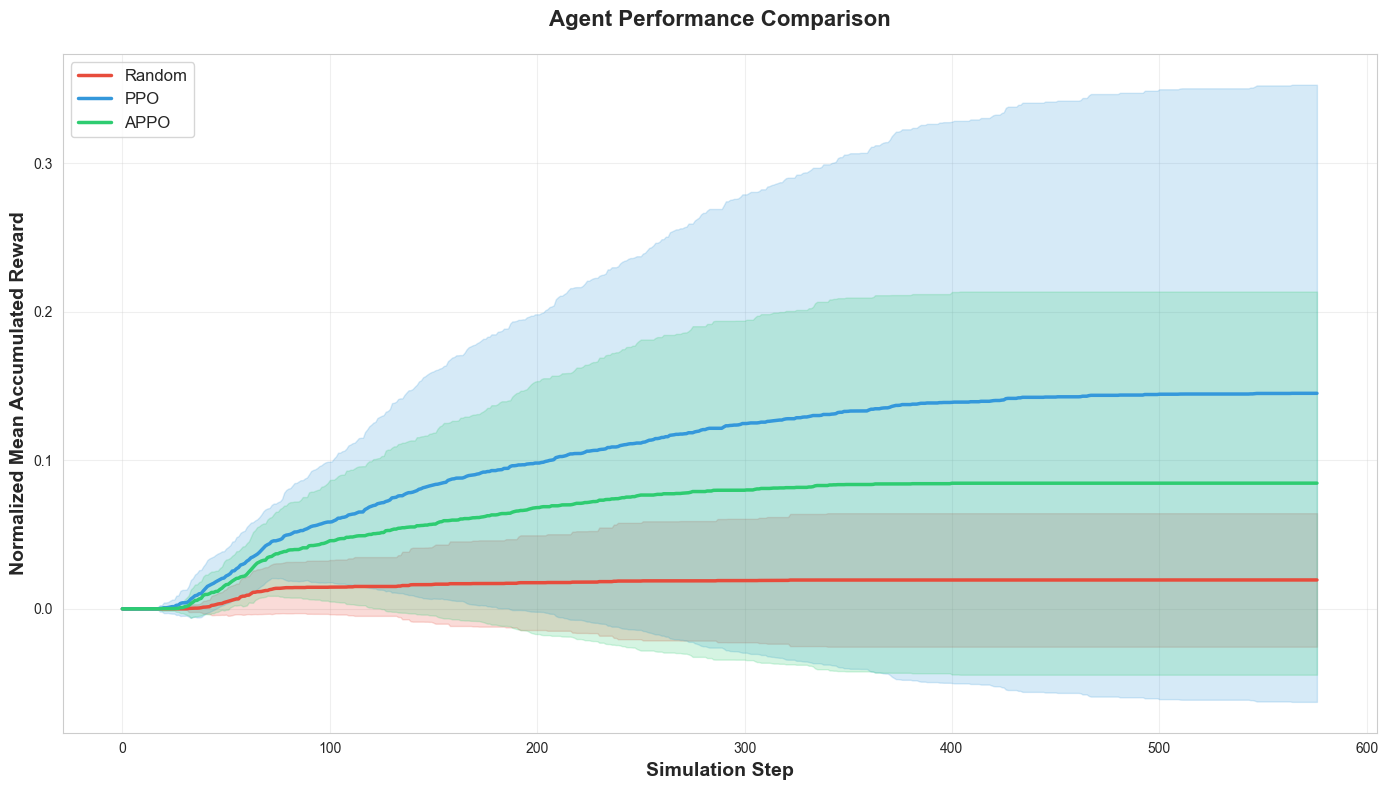

In [6]:
fig, stats = plot_agent_comparison(
    data,
    normalize=True,
    controlled_agent_id="agent_0",
    missing_mode="ffill",
    band="std"
)

In [7]:
fig.savefig(
    "plots/agent_comparison_ppo_appo_random_exp3_new.png",
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

## Boxplot Comparison: H-Index and Lifespan

In [8]:
def plot_hindex_lifespan_comparison(
    data_dict,
    figsize=(16, 6),
    controlled_agent_id="agent_0"
):
    """
    Compare final H-index and lifespan for Random, PPO, and APPO.

    The function uses one comparable evaluation unit per seed:
    - PPO/APPO: archetype == "rl_agent"
    - Random: controlled_agent_id, usually "agent_0"
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    colors = {
        "Random": "#e74c3c",
        "PPO": "#3498db",
        "APPO": "#2ecc71"
    }

    hindex_data = []
    lifespan_data = []
    agent_labels = []
    final_tables = {}

    def filter_comparable_agent(agent_name, traj):
        """Filter to the comparable controlled agent."""
        traj = traj.copy()

        # PPO/APPO: controlled RL agent
        if "archetype" in traj.columns and (traj["archetype"] == "rl_agent").any():
            filtered = traj[traj["archetype"] == "rl_agent"].copy()
            reason = "archetype == 'rl_agent'"
            return filtered, reason

        # Random: same controlled agent id
        if "agent_id" in traj.columns:
            mask = traj["agent_id"].astype(str) == str(controlled_agent_id)
            if mask.any():
                filtered = traj[mask].copy()
                reason = f"agent_id == {controlled_agent_id}"
                return filtered, reason

            # Fallback: first agent per seed
            if "seed" in traj.columns:
                units = traj[["seed", "agent_id"]].drop_duplicates().copy()
                units["__agent_sort"] = units["agent_id"].astype(str)

                selected_units = (
                    units
                    .sort_values(["seed", "__agent_sort"])
                    .groupby("seed", as_index=False)
                    .first()[["seed", "agent_id"]]
                )

                filtered = traj.merge(selected_units, on=["seed", "agent_id"], how="inner")
                reason = f"{controlled_agent_id} not found; first agent per seed"
                return filtered, reason

        return traj, "fallback: all rows"

    for agent_name, agent_data in data_dict.items():
        traj = agent_data["trajectory"].copy()

        if len(traj) == 0:
            print(f"Warning: {agent_name}: empty trajectory.")
            continue

        traj, filter_reason = filter_comparable_agent(agent_name, traj)

        if len(traj) == 0:
            print(f"Warning: {agent_name}: no data after filtering.")
            continue

        if "step" not in traj.columns:
            raise ValueError(f"{agent_name}: Missing column 'step'.")

        # Sort before taking final row
        sort_cols = ["step"]
        if "seed" in traj.columns:
            sort_cols = ["seed"] + sort_cols
        if "agent_id" in traj.columns:
            sort_cols = ["seed", "agent_id", "step"] if "seed" in traj.columns else ["agent_id", "step"]

        traj = traj.sort_values(sort_cols)

        # Get final row per evaluated unit
        if "seed" in traj.columns and "agent_id" in traj.columns:
            final_data = traj.groupby(["seed", "agent_id"], as_index=False).tail(1)
        elif "seed" in traj.columns:
            final_data = traj.groupby("seed", as_index=False).tail(1)
        elif "agent_id" in traj.columns:
            final_data = traj.groupby("agent_id", as_index=False).tail(1)
        else:
            final_data = traj.tail(1)

        print(f"{agent_name}: using {filter_reason}")
        print(f"{agent_name}: N={len(final_data)} final units")

        if "h_index" in final_data.columns:
            h_values = final_data["h_index"].dropna().values
        else:
            h_values = np.array([])

        if "age" in final_data.columns:
            l_values = final_data["age"].dropna().values
        else:
            l_values = np.array([])

        if len(h_values) == 0 and len(l_values) == 0:
            print(f"Warning: {agent_name}: no h_index or age data.")
            continue

        hindex_data.append(h_values)
        lifespan_data.append(l_values)
        agent_labels.append(agent_name)
        final_tables[agent_name] = final_data

    if len(agent_labels) == 0:
        raise ValueError("No valid data available for boxplot.")

    # H-index boxplot
    bp1 = ax1.boxplot(
        hindex_data,
        tick_labels=agent_labels,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        medianprops=dict(color="black", linewidth=2),
        meanprops=dict(color="red", linewidth=2, linestyle="--")
    )

    for patch, label in zip(bp1["boxes"], agent_labels):
        patch.set_facecolor(colors.get(label, "#95a5a6"))
        patch.set_alpha(0.7)

    ax1.set_ylabel("H-Index", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Agent Type", fontsize=12, fontweight="bold")
    ax1.set_title("H-Index Comparison", fontsize=14, fontweight="bold", pad=15)
    ax1.grid(True, alpha=0.3, axis="y")

    # Lifespan boxplot
    bp2 = ax2.boxplot(
        lifespan_data,
        tick_labels=agent_labels,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        medianprops=dict(color="black", linewidth=2),
        meanprops=dict(color="red", linewidth=2, linestyle="--")
    )

    for patch, label in zip(bp2["boxes"], agent_labels):
        patch.set_facecolor(colors.get(label, "#95a5a6"))
        patch.set_alpha(0.7)

    ax2.set_ylabel("Lifespan (Age)", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Agent Type", fontsize=12, fontweight="bold")
    ax2.set_title("Lifespan Comparison", fontsize=14, fontweight="bold", pad=15)
    ax2.grid(True, alpha=0.3, axis="y")

    from matplotlib.lines import Line2D

    legend = [
        Line2D([0], [0], color="black", linewidth=2, label="Median"),
        Line2D([0], [0], color="red", linewidth=2, linestyle="--", label="Mean")
    ]

    ax1.legend(handles=legend, loc="upper right")
    ax2.legend(handles=legend, loc="upper right")

    plt.tight_layout()

    print("\n" + "=" * 80)
    print("H-Index and Lifespan Statistics")
    print("=" * 80)

    for i, agent_name in enumerate(agent_labels):
        h_values = hindex_data[i]
        l_values = lifespan_data[i]

        h_mean = np.mean(h_values) if len(h_values) > 0 else np.nan
        h_med = np.median(h_values) if len(h_values) > 0 else np.nan
        h_std = np.std(h_values, ddof=1) if len(h_values) > 1 else 0.0

        l_mean = np.mean(l_values) if len(l_values) > 0 else np.nan
        l_med = np.median(l_values) if len(l_values) > 0 else np.nan
        l_std = np.std(l_values, ddof=1) if len(l_values) > 1 else 0.0

        print(
            f"{agent_name:<10} | "
            f"H-Index: mean={h_mean:.2f}, median={h_med:.2f}, std={h_std:.2f}, n={len(h_values)} | "
            f"Lifespan: mean={l_mean:.2f}, median={l_med:.2f}, std={l_std:.2f}, n={len(l_values)}"
        )

    return fig, {
        "hindex": hindex_data,
        "lifespan": lifespan_data,
        "labels": agent_labels,
        "final_tables": final_tables
    }

Random: using agent_id == agent_0
Random: N=100 final units
PPO: using archetype == 'rl_agent'
PPO: N=100 final units
APPO: using archetype == 'rl_agent'
APPO: N=100 final units

H-Index and Lifespan Statistics
Random     | H-Index: mean=0.20, median=0.00, std=0.72, n=100 | Lifespan: mean=73.39, median=70.50, std=34.49, n=100
PPO        | H-Index: mean=2.34, median=2.00, std=2.55, n=100 | Lifespan: mean=140.14, median=74.00, std=124.63, n=100
APPO       | H-Index: mean=1.64, median=0.00, std=2.29, n=100 | Lifespan: mean=110.93, median=73.00, std=87.46, n=100


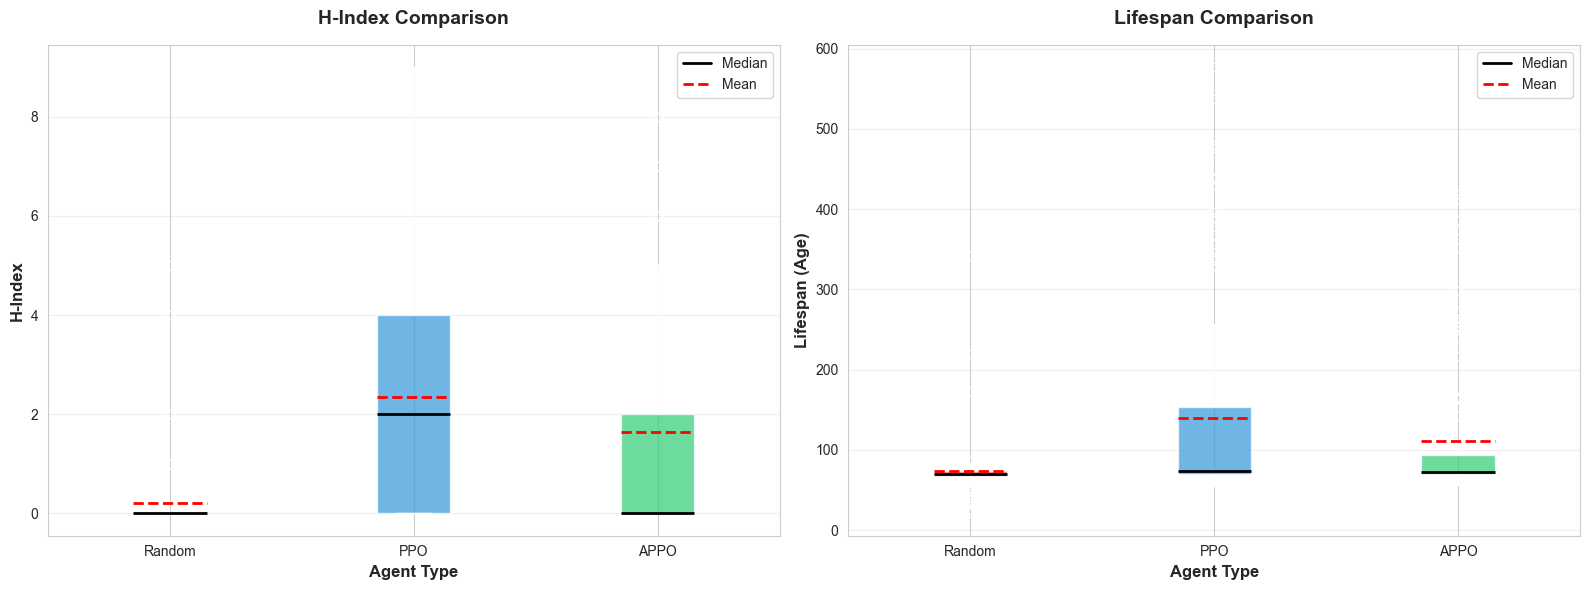

In [9]:
# Create boxplot
fig_box, box_stats = plot_hindex_lifespan_comparison(data)
plt.show()

In [10]:
fig_box.savefig(
    "plots/hindex_lifespan_comparison_ppo_appo_random_exp3.png",
    dpi=600,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

## Save Plots

In [11]:
# Create output directory
output_dir = Path('../plots')
output_dir.mkdir(exist_ok=True)

# Save reward trajectory plot
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
fig.savefig(output_dir / f'AgentComparison_{timestamp}.png', dpi=300, bbox_inches='tight')
print(f"Saved reward plot to: {output_dir}/AgentComparison_{timestamp}.png")

# Save boxplot
fig_box.savefig(output_dir / f'AgentComparison_HIndex_Lifespan_{timestamp}.png', dpi=300, bbox_inches='tight')
print(f"Saved boxplot to: {output_dir}/AgentComparison_HIndex_Lifespan_{timestamp}.png")

Saved reward plot to: ..\plots/AgentComparison_20260606_172725.png
Saved boxplot to: ..\plots/AgentComparison_HIndex_Lifespan_20260606_172725.png


In [12]:
from scipy import stats

def mann_whitney_test(group1, group2, label1, label2, metric_name, alpha=0.005):
    """
    Perform Mann-Whitney U test between two groups.

    Parameters:
    -----------
    group1, group2 : array-like
        Data for the two groups to compare
    label1, label2 : str
        Names of the groups
    metric_name : str
        Name of the metric being tested
    alpha : float
        Significance level (default: 0.005)
    """
    # Remove NaN values
    group1_clean = np.array(group1)[~np.isnan(group1)]
    group2_clean = np.array(group2)[~np.isnan(group2)]

    # Perform Mann-Whitney U test
    statistic, p_value = stats.mannwhitneyu(group1_clean, group2_clean, alternative='two-sided')

    # Calculate descriptive statistics
    median1 = np.median(group1_clean)
    median2 = np.median(group2_clean)
    mean1 = np.mean(group1_clean)
    mean2 = np.mean(group2_clean)

    # Determine significance
    is_significant = p_value < alpha

    print(f"\n{metric_name}: {label1} vs {label2}")
    print("-" * 80)
    print(f"{label1:12s} - Median: {median1:8.2f}, Mean: {mean1:8.2f}, N: {len(group1_clean):5d}")
    print(f"{label2:12s} - Median: {median2:8.2f}, Mean: {mean2:8.2f}, N: {len(group2_clean):5d}")
    print(f"U-statistic: {statistic:.2f}")
    print(f"p-value:     {p_value:.6f}")
    print(f"Significant: {'YES ✓' if is_significant else 'NO ✗'} (α={alpha})")

    return {
        'statistic': statistic,
        'p_value': p_value,
        'significant': is_significant,
        'median1': median1,
        'median2': median2,
        'mean1': mean1,
        'mean2': mean2,
        'n1': len(group1_clean),
        'n2': len(group2_clean)
    }

In [13]:
# Extract final accumulated rewards for each agent type
performance_data = {}

for agent_name, final_table in box_stats['final_tables'].items():
    if 'accumulated_rewards' in final_table.columns:
        performance_data[agent_name] = final_table['accumulated_rewards'].dropna().values
    else:
        print(f"Warning: {agent_name} has no accumulated_rewards column")

print("=" * 90)
print("PERFORMANCE COMPARISON - Mann-Whitney U Tests (p < 0.005)")
print("=" * 90)

# PPO vs APPO
if 'PPO' in performance_data and 'APPO' in performance_data:
    result_ppo_appo = mann_whitney_test(
        performance_data['PPO'],
        performance_data['APPO'],
        'PPO',
        'APPO',
        'Performance',
        alpha=0.005
    )

# PPO vs Random
if 'PPO' in performance_data and 'Random' in performance_data:
    result_ppo_random = mann_whitney_test(
        performance_data['PPO'],
        performance_data['Random'],
        'PPO',
        'Random',
        'Performance',
        alpha=0.005
    )

PERFORMANCE COMPARISON - Mann-Whitney U Tests (p < 0.005)

Performance: PPO vs APPO
--------------------------------------------------------------------------------
PPO          - Median:     0.97, Mean:     3.05, N:   100
APPO         - Median:     0.58, Mean:     1.78, N:   100
U-statistic: 6450.00
p-value:     0.000398
Significant: YES ✓ (α=0.005)

Performance: PPO vs Random
--------------------------------------------------------------------------------
PPO          - Median:     0.97, Mean:     3.05, N:   100
Random       - Median:     0.16, Mean:     0.41, N:   100
U-statistic: 8817.50
p-value:     0.000000
Significant: YES ✓ (α=0.005)


In [14]:
print("\n" + "=" * 90)
print("LIFESPAN COMPARISON - Mann-Whitney U Tests (p < 0.005)")
print("=" * 90)

# Get lifespan data from box_stats
lifespan_dict = {
    label: data
    for label, data in zip(box_stats['labels'], box_stats['lifespan'])
}

# PPO vs APPO
if 'PPO' in lifespan_dict and 'APPO' in lifespan_dict:
    result_lifespan_ppo_appo = mann_whitney_test(
        lifespan_dict['PPO'],
        lifespan_dict['APPO'],
        'PPO',
        'APPO',
        'Lifespan (Age)',
        alpha=0.005
    )

# PPO vs Random
if 'PPO' in lifespan_dict and 'Random' in lifespan_dict:
    result_lifespan_ppo_random = mann_whitney_test(
        lifespan_dict['PPO'],
        lifespan_dict['Random'],
        'PPO',
        'Random',
        'Lifespan (Age)',
        alpha=0.005
    )


LIFESPAN COMPARISON - Mann-Whitney U Tests (p < 0.005)

Lifespan (Age): PPO vs APPO
--------------------------------------------------------------------------------
PPO          - Median:    74.00, Mean:   140.14, N:   100
APPO         - Median:    73.00, Mean:   110.93, N:   100
U-statistic: 5571.00
p-value:     0.162850
Significant: NO ✗ (α=0.005)

Lifespan (Age): PPO vs Random
--------------------------------------------------------------------------------
PPO          - Median:    74.00, Mean:   140.14, N:   100
Random       - Median:    70.50, Mean:    73.39, N:   100
U-statistic: 6873.00
p-value:     0.000005
Significant: YES ✓ (α=0.005)


In [15]:
print("\n" + "=" * 90)
print("H-INDEX COMPARISON - Mann-Whitney U Tests (p < 0.005)")
print("=" * 90)

# Get H-index data from box_stats
hindex_dict = {
    label: data
    for label, data in zip(box_stats['labels'], box_stats['hindex'])
}

# PPO vs APPO
if 'PPO' in hindex_dict and 'APPO' in hindex_dict:
    result_hindex_ppo_appo = mann_whitney_test(
        hindex_dict['PPO'],
        hindex_dict['APPO'],
        'PPO',
        'APPO',
        'H-Index',
        alpha=0.005
    )

# PPO vs Random
if 'PPO' in hindex_dict and 'Random' in hindex_dict:
    result_hindex_ppo_random = mann_whitney_test(
        hindex_dict['PPO'],
        hindex_dict['Random'],
        'PPO',
        'Random',
        'H-Index',
        alpha=0.005
    )


H-INDEX COMPARISON - Mann-Whitney U Tests (p < 0.005)

H-Index: PPO vs APPO
--------------------------------------------------------------------------------
PPO          - Median:     2.00, Mean:     2.34, N:   100
APPO         - Median:     0.00, Mean:     1.64, N:   100
U-statistic: 5931.50
p-value:     0.016861
Significant: NO ✗ (α=0.005)

H-Index: PPO vs Random
--------------------------------------------------------------------------------
PPO          - Median:     2.00, Mean:     2.34, N:   100
Random       - Median:     0.00, Mean:     0.20, N:   100
U-statistic: 7882.00
p-value:     0.000000
Significant: YES ✓ (α=0.005)


In [16]:
# Create summary table of all significance tests
print("\n" + "=" * 90)
print("SUMMARY OF STATISTICAL SIGNIFICANCE TESTS")
print("=" * 90)
print(f"Significance level: α = 0.005 (p < 0.005)")
print("=" * 90)

results_summary = []

# Performance tests
if 'PPO' in performance_data and 'APPO' in performance_data:
    results_summary.append({
        'Metric': 'Performance',
        'Comparison': 'PPO vs APPO',
        'p-value': result_ppo_appo['p_value'],
        'Significant': '✓' if result_ppo_appo['significant'] else '✗'
    })

if 'PPO' in performance_data and 'Random' in performance_data:
    results_summary.append({
        'Metric': 'Performance',
        'Comparison': 'PPO vs Random',
        'p-value': result_ppo_random['p_value'],
        'Significant': '✓' if result_ppo_random['significant'] else '✗'
    })

# H-index tests
if 'PPO' in hindex_dict and 'APPO' in hindex_dict:
    results_summary.append({
        'Metric': 'H-Index',
        'Comparison': 'PPO vs APPO',
        'p-value': result_hindex_ppo_appo['p_value'],
        'Significant': '✓' if result_hindex_ppo_appo['significant'] else '✗'
    })

if 'PPO' in hindex_dict and 'Random' in hindex_dict:
    results_summary.append({
        'Metric': 'H-Index',
        'Comparison': 'PPO vs Random',
        'p-value': result_hindex_ppo_random['p_value'],
        'Significant': '✓' if result_hindex_ppo_random['significant'] else '✗'
    })

# Lifespan tests
if 'PPO' in lifespan_dict and 'APPO' in lifespan_dict:
    results_summary.append({
        'Metric': 'Lifespan',
        'Comparison': 'PPO vs APPO',
        'p-value': result_lifespan_ppo_appo['p_value'],
        'Significant': '✓' if result_lifespan_ppo_appo['significant'] else '✗'
    })

if 'PPO' in lifespan_dict and 'Random' in lifespan_dict:
    results_summary.append({
        'Metric': 'Lifespan',
        'Comparison': 'PPO vs Random',
        'p-value': result_lifespan_ppo_random['p_value'],
        'Significant': '✓' if result_lifespan_ppo_random['significant'] else '✗'
    })

# Print summary table
summary_df = pd.DataFrame(results_summary)
print(summary_df.to_string(index=False))
print("=" * 90)


SUMMARY OF STATISTICAL SIGNIFICANCE TESTS
Significance level: α = 0.005 (p < 0.005)
     Metric    Comparison      p-value Significant
Performance   PPO vs APPO 3.975291e-04           ✓
Performance PPO vs Random 9.704497e-21           ✓
    H-Index   PPO vs APPO 1.686112e-02           ✗
    H-Index PPO vs Random 6.610256e-16           ✓
   Lifespan   PPO vs APPO 1.628497e-01           ✗
   Lifespan PPO vs Random 4.647948e-06           ✓
